- Topic: **Immunity acquisition** scheme
- Creation date: 07/2025
- Author: Miguel Garrido Zornoza (mgarrizoraca@gmail.com)

In [6]:
from datetime import datetime
from IPython.display import display, Markdown

todays_date = str(datetime.now().date())

display(Markdown(f'#### Last update: {todays_date}'))

#### Last update: 2025-07-17

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as colors

The two-time scale scheme for immunity acquisition upon infective bite reads as

$$ e_l^{+} = e_0 \cdot \left[A_1 \cdot exp(-e_l/e_1) + (1-A_1) \cdot exp(-e_l/e_2) \right]$$

$$ \approx e_0 \cdot \left[A_1 \cdot exp(-e_l/e_1) + (1-A_1) \cdot (1 -e_l/e_2) \right]$$

The number of infective bites, $N$, needed to be at maximum level of immunity is

$$ \sum_{n = 0}^{N} e_l^{+}(e_l) \sim 1$$

Let's write a function to obtain $N$.

In [117]:
def delta(x,e1,e2,e0,A1):
    return A1*e0*np.exp(-x/e1) + (1-A1)*e0*np.exp(-x/e2)

def sum_to_one(e0,e1,e2,A1):
    summ = 0.
    counter = 0
    cycle = True
    while cycle:
        summ += delta(summ,e1,e2,e0,A1)
        counter += 1

        if (summ >= 1.):
            cycle = False
    return counter

The scheme has $4$ undefined parameters: $e_0$, $e_1$, $e_2$ and $A_1$.

We need a constraint - such as the average life time a person should get maximum immunity in a highly endemic area (EIR ~ 150).

- Constant EIR (no seasonality). Uses annual average.
- Immunity decay is not included.
- Provides a rough estimate of a lower bound to the total time.
  
The number of successes, $r$, are fixed. They must be such that 

$$ \sum_{i = 0}^{r} e_l^{+}(e_l) \sim 1$$ 

The distribution of immunity acquistion times, $t$, comes from the distribution of successes and failures, which in turn depend on the EIR.

The number of failures, $k$, for a predifined number of successes, $r$, and a probability of success per trial $p = 1 - e^{EIP \cdot P_{v0}}$ follows a Negative Binomial (NB) distribution  

$$ NB(k;r,p) = \binom{k+r-1}{k} \cdot (1-p)^k \cdot p^r = \frac{(k+r-1)!}{(r-1)!k!} \cdot (1-p)^k \cdot p^r  = \frac{\Gamma(k+r)}{k! \ \Gamma(r)} \cdot (1-p)^k \cdot p^r$$

The time, $t$, after $N=k+r$ trials is composed by $1$ day per unsuccessful trial and $IPP$ days per successul trial.

$$ t = k + r \cdot IIP$$

The distribution of $t$ is just shifted by a factor $r \cdot IPP$ with respect to $NB(k;r,p)$.


The mean is then 

$$ \mu_{NB} = \frac{r (1-p)}{p} + r \cdot IPP = r \cdot \left( \frac{1-p}{p} + IPP \right)$$

with a variance of

$$ \sigma^2 \sim \frac{\mu_{NB}}{p} $$ 

In [119]:
A1 = 0.9
A2 = 1-A1
IPP = 10
EIR_day = 150/365
P_v0 = 0.3
p = 1-np.exp(-EIR_day*P_v0)
N = np.zeros((300,300))

for i,e0 in tqdm(enumerate(np.linspace(0.03,0.2,300))):
    e2 = 10*e0
    for j,e1 in enumerate(np.linspace(0.1,3,300)):
        e1 = e1*e0    
        N[i][j] = sum_to_one(e0,e1,e2,A1)*((1-p)/p + IPP)

300it [00:25, 11.66it/s]


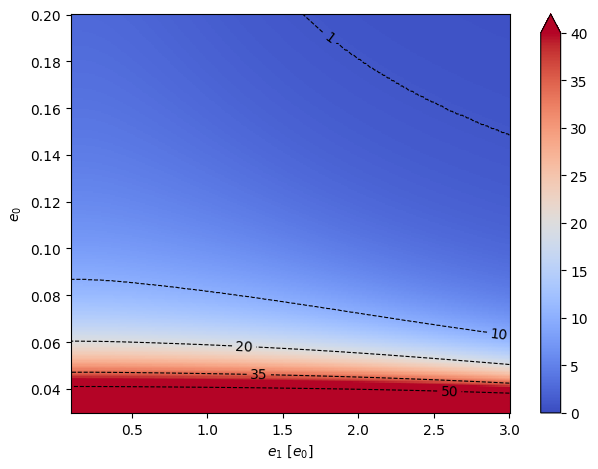

In [121]:
X, Y = np.meshgrid(np.linspace(0.1,3,300),np.linspace(0.03,0.2,300))

fig, ax = plt.subplots()
CM = plt.contour(X, Y, N/365, levels=[1,10,20,35,50], colors='k', linestyles = "dashed", linewidths=0.8) # 10 levels, white lines
ax.clabel(CM, CM.levels)

#cb = plt.contourf(X, Y, N/365, levels=500, cmap = "coolwarm", vmin = 0, vmax = 45)
#fig.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max")

cb = plt.pcolor(X, Y, N/365, cmap = "coolwarm", vmin = 0, vmax = 45)
plt.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max")
plt.clim(0,40)

plt.ylabel(r"$e_0$")
plt.xlabel(r"$e_1 \ [e_0]$")
plt.tight_layout()

Is $A_1$ relevant?

In [122]:
A1 = 0.6
A2 = 1-A1
IPP = 10
EIR_day = 150/365
P_v0 = 0.3
p = 1-np.exp(-EIR_day*P_v0)
N = np.zeros((300,300))

for i,e0 in tqdm(enumerate(np.linspace(0.03,0.2,300))):
    e2 = 10*e0
    for j,e1 in enumerate(np.linspace(0.1,3,300)):
        e1 = e1*e0    
        N[i][j] = sum_to_one(e0,e1,e2,A1)*((1-p)/p + IPP)

300it [00:07, 41.12it/s] 


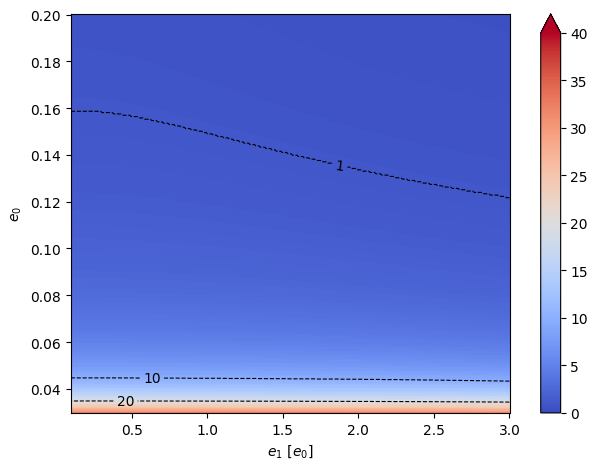

In [123]:
X, Y = np.meshgrid(np.linspace(0.1,3,300),np.linspace(0.03,0.2,300))

fig, ax = plt.subplots()
CM = plt.contour(X, Y, N/365, levels=[1,10,20,35,50], colors='k', linestyles = "dashed", linewidths=0.8) # 10 levels, white lines
ax.clabel(CM, CM.levels)

#cb = plt.contourf(X, Y, N/365, levels=500, cmap = "coolwarm", vmin = 0, vmax = 45)
#fig.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max")

cb = plt.pcolor(X, Y, N/365, cmap = "coolwarm", vmin = 0, vmax = 45)
plt.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max")
plt.clim(0,40)

plt.ylabel(r"$e_0$")
plt.xlabel(r"$e_1 \ [e_0]$")
plt.tight_layout()

/var/folders/14/l51zqrvj2d9_1sh39790xhl80000gn/T/ipykernel_3149/4190538610.py:2: RuntimeWarning: divide by zero encountered in divide
  return A1*e0*np.exp(-x/e1) + (1-A1)*e0*np.exp(-x/e2)
/var/folders/14/l51zqrvj2d9_1sh39790xhl80000gn/T/ipykernel_3149/4190538610.py:2: RuntimeWarning: invalid value encountered in divide
  return A1*e0*np.exp(-x/e1) + (1-A1)*e0*np.exp(-x/e2)


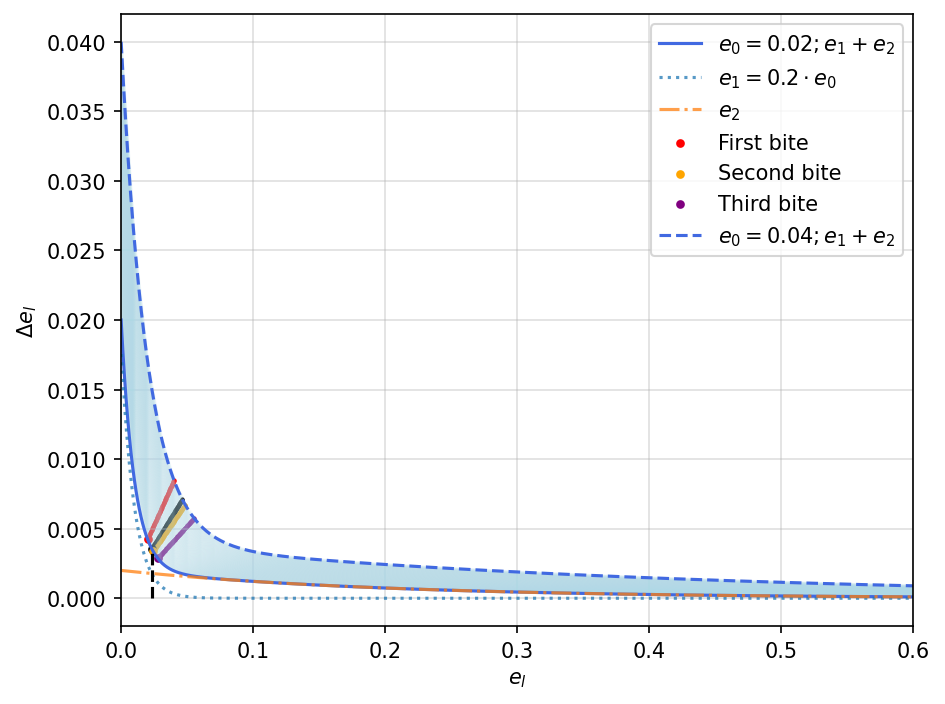

In [14]:
A1 = 0.9
A2 = 1-A1
x = np.linspace(0,1,100)

plt.subplots(dpi=150)

for e_0 in np.linspace(0.02,0.04,100):
    e1 = 0.5*e_0
    e2 = 10*e_0
    plt.plot(x,delta(x,e1,e2,e_0,A1), color = "lightblue", alpha = 0.1)

    x0 = delta(0,e1,e2,e_0,A1)
    x1 = delta(x0,e1,e2,e_0,A1)
    x2 = delta(x0+x1,e1,e2,e_0,A1)
    x3 = delta(x0+x1+x2,e1,e2,e_0,A1)

    plt.scatter(x0,x1, color = "red", s = 1)
    plt.scatter(x0+x1,x2, color = "orange", s = 1)
    plt.scatter(x0+x1+x2,x3, color = "purple", s = 1)
    
    x_t = np.log(A1/(1-A1))*(e1*e2/(e2-e1))
    plt.scatter(x_t,delta(x_t,e1,e2,e_0,A1), color = "k", s = 1)

e_0 = 0.02
e1 = 0.5*e_0
e2 = 10*e_0
x = np.linspace(0,1,4000)

x_t = np.log(A1/(1-A1))*(e1*e2/(e2-e1))

plt.plot(x,delta(x,e1,e2,e_0,A1),color = "royalblue", label = r"$e_0 ="+f"{e_0:.2f}"+"; e_1+e_2$")

plt.plot(x,delta(x,e1,0,e_0,A1), alpha = 0.75, ls = "dotted", label = r"$e_1 = 0.2 \cdot e_0$")
plt.plot(x,delta(x,0,e2,e_0,A1), alpha = 0.75, ls = "-.", label = r"$e_2$")

plt.vlines(x_t,0,delta(x_t,e1,e2,e_0,A1), ls = "dashed", color = "k")
plt.scatter(x_t,delta(x_t,e1,e2,e_0,A1), color = "k", s = 10)

x0 = delta(0,e1,e2,e_0,A1)
x1 = delta(x0,e1,e2,e_0,A1)
x2 = delta(x0+x1,e1,e2,e_0,A1)
x3 = delta(x0+x1+x2,e1,e2,e_0,A1)

plt.scatter(x0,x1, color = "red", label = "First bite", s = 10)
plt.scatter(x0+x1,x2, color = "orange", label = "Second bite", s = 10)
plt.scatter(x0+x1+x2,x3, color = "purple", label = "Third bite", s = 10)

e_0 = 0.04
e1 = 0.5*e_0
e2 = 10*e_0

plt.plot(x,delta(x,e1,e2,e_0,A1),ls = "dashed", color = "royalblue", label = r"$e_0 ="+f"{e_0:.2f}"+"; e_1+e_2$")

plt.legend()
plt.ylabel(r"$Δe_l$")
plt.xlabel(r"$e_l$")
plt.grid(alpha=0.4)

plt.xlim(0,0.6)
plt.tight_layout()

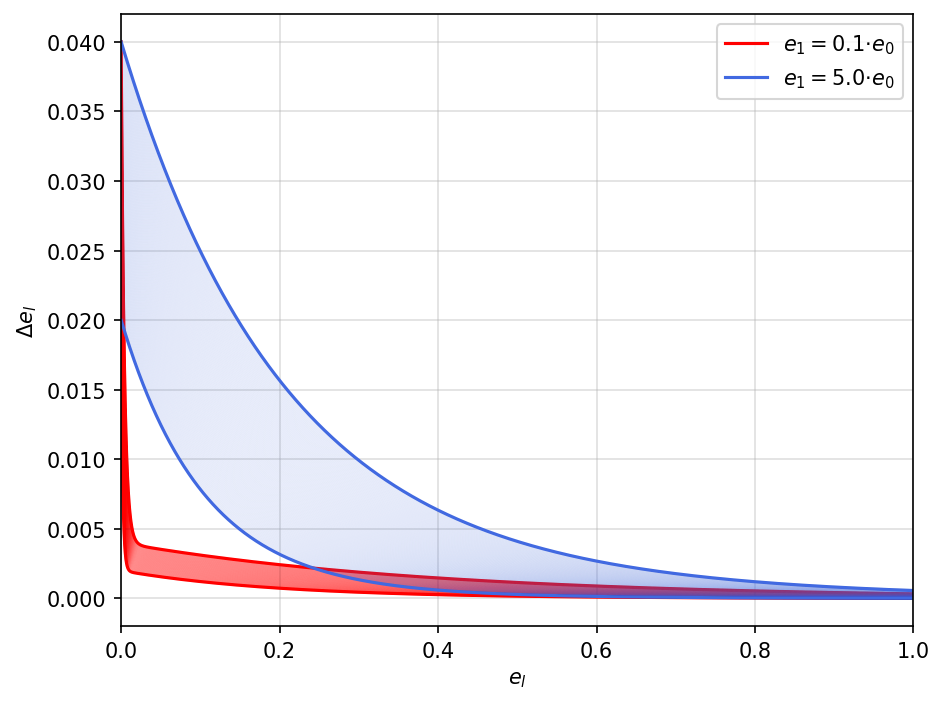

In [28]:
A1 = 0.9
A2 = 1-A1

color_list = ["red","royalblue","green"]

plt.subplots(dpi=150)

x = np.linspace(0,1,4000)
indx = 0

for coeff in [0.1,5]:
    for e_0 in [0.02,0.04]:
        e1 = coeff*e_0
        e2 = 10*e_0
    
        x_t = np.log(A1/(1-A1))*(e1*e2/(e2-e1))

        if e_0 == 0.02:
            plt.plot(x,delta(x,e1,e2,e_0,A1),color = color_list[indx], label = r"$e_1 =$"+f"{coeff:.1f}"+r"$\cdot e_0$")
        else:
            plt.plot(x,delta(x,e1,e2,e_0,A1),color = color_list[indx])

    for e_0 in np.linspace(0.02,0.04,100):
        e1 = coeff*e_0
        e2 = 10*e_0
        plt.plot(x,delta(x,e1,e2,e_0,A1), color = color_list[indx], alpha = 0.05)

    indx += 1

plt.legend()
plt.ylabel(r"$Δe_l$")
plt.xlabel(r"$e_l$")
plt.grid(alpha=0.4)

plt.xlim(0,1)
plt.tight_layout()

$$ e^* = ln\left(\frac{A_1}{1 - A_1} \right) \cdot \frac{e_1 \cdot e_2}{e_2 - e_1}$$

Number of infective bites to surpass fast acquisition scale

$$ \sum_{n = 0}^{N} e_l^{+}(e_l) \ge e^* = ln\left(\frac{A_1}{1 - A_1} \right) \cdot \frac{e_1 \cdot e_2}{e_2 - e_1}$$

In [49]:
def sum_to_fast(e0,e1,e2,A1):
    fast = np.log(A1/(1-A1)) * (e1*e2/(e2-e1))
    summ = 0.
    counter = 0
    cycle = True
    while cycle:
        summ += delta(summ,e1,e2,e0,A1)
        counter += 1

        if (summ >= fast):
            cycle = False
    return counter

In [87]:
N = np.zeros((300,300))
for i,e0 in tqdm(enumerate(np.linspace(0.03,0.2,300))):
    for j,e1 in enumerate(np.linspace(0.1,3,300)):
        e1 = e1*e0     
        N[i][j] = sum_to_fast(e0,e1,e2,A1)

300it [00:03, 86.00it/s] 


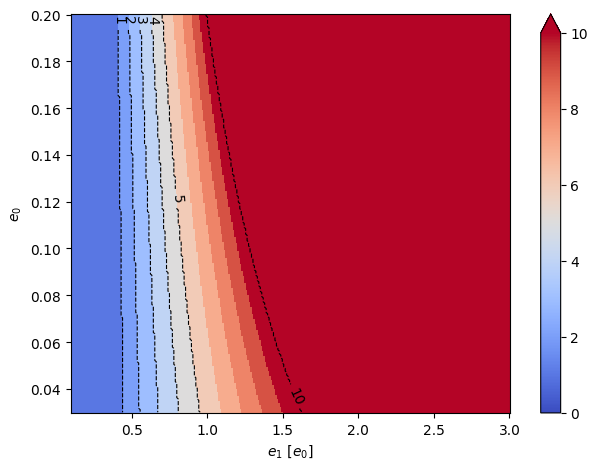

In [88]:
fig, ax = plt.subplots()

X, Y = np.meshgrid(np.linspace(0.1,3,300),np.linspace(0.03,0.2,300))

CM = plt.contour(X, Y, N, levels=[1,2,3,4,5,10], colors='k', linestyles = "dashed", linewidths=0.8) # 10 levels, white lines
ax.clabel(CM, CM.levels)

cb = plt.pcolor(X, Y, N, cmap = "coolwarm", vmin = 0, vmax = 10)
plt.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max")
plt.clim(0,10)

plt.ylabel(r"$e_0$")
plt.xlabel(r"$e_1 \ [e_0]$")
plt.tight_layout()

In [89]:
path_1 = CM.collections[0].get_paths()[0].to_polygons()
path_2 = CM.collections[1].get_paths()[0].to_polygons()
path_3 = CM.collections[2].get_paths()[0].to_polygons()

In [90]:
x_1 = np.array(path_1[0])[:,0]
y_1 = np.array(path_1[0])[:,1]

x_2 = np.array(path_2[0])[:,0]
y_2 = np.array(path_2[0])[:,1]

x_3 = np.array(path_3[0])[:,0]
y_3 = np.array(path_3[0])[:,1]

In [91]:
A1 = 0.9
A2 = 1-A1
IPP = 10
EIR_day = 150/365
P_v0 = 0.3
p = 1-np.exp(-EIR_day*P_v0)
N = np.zeros((300,300))

for i,e0 in tqdm(enumerate(np.linspace(0.03,0.2,300))):
    e2 = 10*e0
    for j,e1 in enumerate(np.linspace(0.1,3,300)):
        e1 = e1*e0    
        N[i][j] = sum_to_one(e0,e1,e2,A1)*((1-p)/p + IPP)

300it [00:25, 11.81it/s]


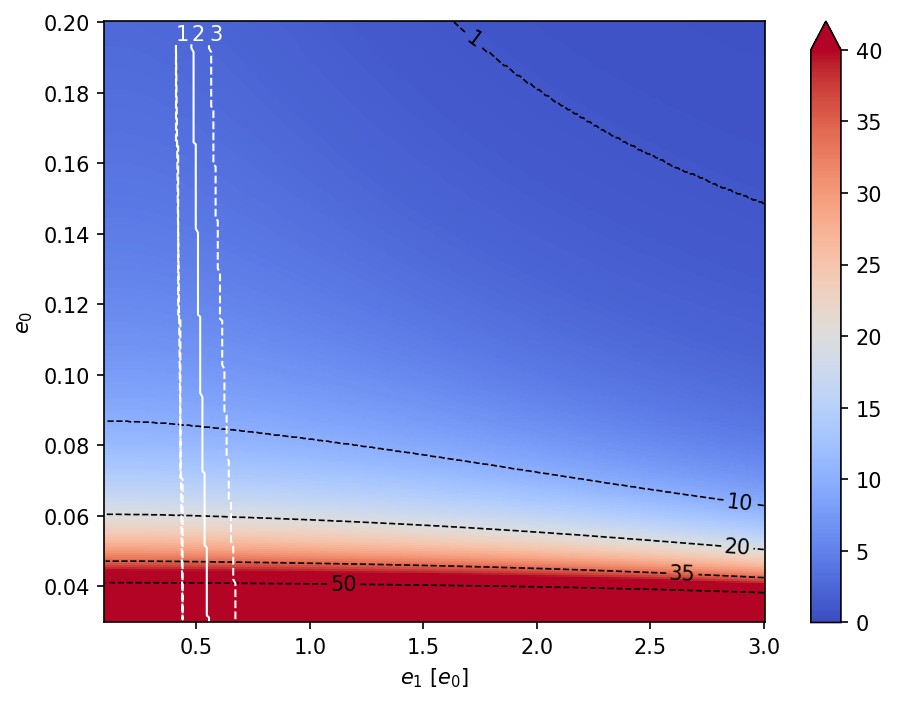

In [113]:
X, Y = np.meshgrid(np.linspace(0.1,3,300),np.linspace(0.03,0.2,300))

fig, ax = plt.subplots(dpi = 150)
CM = plt.contour(X, Y, N/365, levels=[1,10,20,35,50], colors='k', linestyles = "dashed", linewidths=0.8) # 10 levels, white lines
ax.clabel(CM, CM.levels)

plt.plot(x_1[::2],y_1[::2], ls = "dashed", color = "white", lw = 1)
plt.plot(x_2[::2],y_2[::2], ls = "solid", color = "white", lw = 1)
plt.plot(x_3[::2],y_3[::2], ls = "dashed", color = "white", lw = 1)

plt.text(np.min(x_1[::2]),np.max(y_1[::2])+0.0015,"1", color = "white")
plt.text(np.min(x_2[::2]),np.max(y_2[::2])+0.0015,"2", color = "white")
plt.text(np.min(x_3[::2]),np.max(y_3[::2])+0.0015,"3", color = "white")

cb = plt.pcolor(X, Y, N/365, cmap = "coolwarm", vmin = 0, vmax = 45)
plt.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max")
plt.clim(0,40)

plt.ylabel(r"$e_0$")
plt.xlabel(r"$e_1 \ [e_0]$")
plt.tight_layout()

/var/folders/14/l51zqrvj2d9_1sh39790xhl80000gn/T/ipykernel_3149/4190538610.py:2: RuntimeWarning: divide by zero encountered in divide
  return A1*e0*np.exp(-x/e1) + (1-A1)*e0*np.exp(-x/e2)
/var/folders/14/l51zqrvj2d9_1sh39790xhl80000gn/T/ipykernel_3149/4190538610.py:2: RuntimeWarning: invalid value encountered in divide
  return A1*e0*np.exp(-x/e1) + (1-A1)*e0*np.exp(-x/e2)


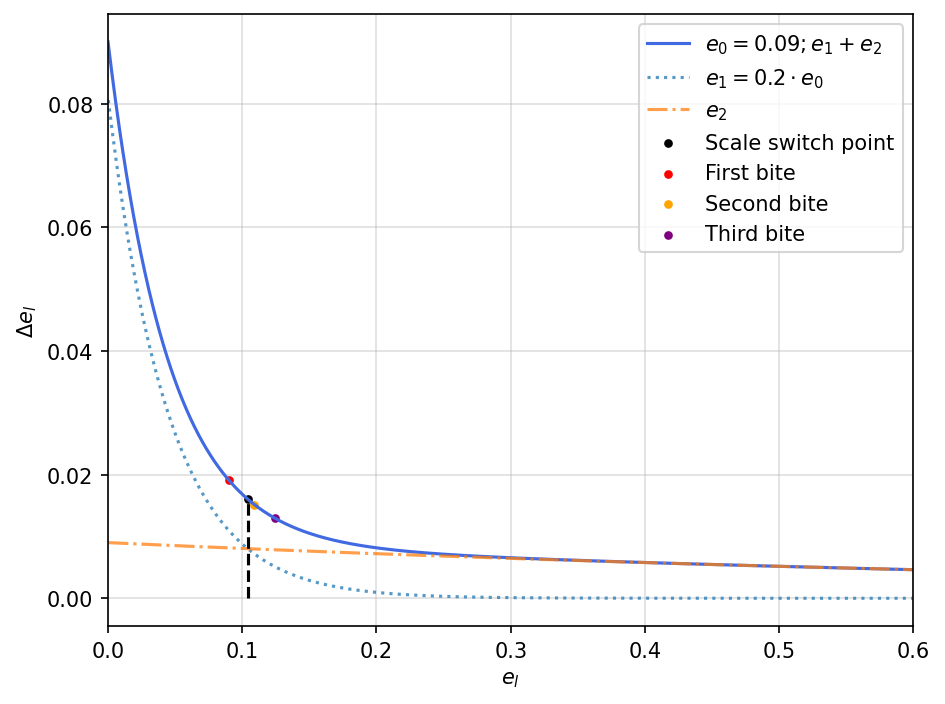

In [125]:
A1 = 0.9
A2 = 1-A1
x = np.linspace(0,1,100)

plt.subplots(dpi=150)

e_0 = 0.09
e1 = 0.5*e_0
e2 = 10*e_0
x = np.linspace(0,1,4000)

x_t = np.log(A1/(1-A1))*(e1*e2/(e2-e1))

plt.plot(x,delta(x,e1,e2,e_0,A1),color = "royalblue", label = r"$e_0 ="+f"{e_0:.2f}"+"; e_1+e_2$")

plt.plot(x,delta(x,e1,0,e_0,A1), alpha = 0.75, ls = "dotted", label = r"$e_1 = 0.2 \cdot e_0$")
plt.plot(x,delta(x,0,e2,e_0,A1), alpha = 0.75, ls = "-.", label = r"$e_2$")

plt.vlines(x_t,0,delta(x_t,e1,e2,e_0,A1), ls = "dashed", color = "k")
plt.scatter(x_t,delta(x_t,e1,e2,e_0,A1), color = "k", s = 10, label = "Scale switch point")

x0 = delta(0,e1,e2,e_0,A1)
x1 = delta(x0,e1,e2,e_0,A1)
x2 = delta(x0+x1,e1,e2,e_0,A1)
x3 = delta(x0+x1+x2,e1,e2,e_0,A1)

plt.scatter(x0,x1, color = "red", label = "First bite", s = 10)
plt.scatter(x0+x1,x2, color = "orange", label = "Second bite", s = 10)
plt.scatter(x0+x1+x2,x3, color = "purple", label = "Third bite", s = 10)

plt.legend()
plt.ylabel(r"$Δe_l$")
plt.xlabel(r"$e_l$")
plt.grid(alpha=0.4)

plt.xlim(0,0.6)
plt.tight_layout()